In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load data dari folder raw
df = pd.read_csv('../dataset_raw/housing_raw.csv')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Jumlah Data Kosong:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


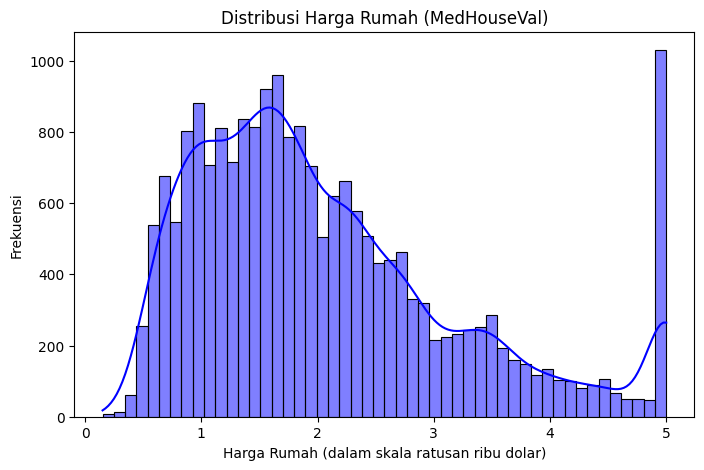

In [2]:
# Cek info data dan missing values
print(df.info())
print("\nJumlah Data Kosong:\n", df.isnull().sum())

# Visualisasi target (MedHouseVal = Median House Value / Harga Rumah)
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='blue')
plt.title('Distribusi Harga Rumah (MedHouseVal)')
plt.xlabel('Harga Rumah (dalam skala ratusan ribu dolar)')
plt.ylabel('Frekuensi')
plt.show()

In [3]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Scaling data (Sangat penting agar model Machine Learning tidak bias)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Menggabungkan kembali untuk disimpan sebagai data bersih
df_processed = X_scaled.copy()
df_processed['MedHouseVal'] = y

# Simpan ke folder preprocessing
df_processed.to_csv('housing_processed.csv', index=False)
print("Data bersih berhasil disimpan sebagai housing_processed.csv!")

Data bersih berhasil disimpan sebagai housing_processed.csv!
